Goal: Label the rail track patches created from OSDAR23 dataset and create masks for defective ones

# All the required libraries

In [ ]:
#Environment
%env OMP_NUM_THREADS=6
import os
os.environ["OMP_NUM_THREADS"] = "6"

# Standards
import ast
import json
import math
import pathlib
import random
import re
import shutil
import warnings
from collections import Counter, defaultdict
from datetime import datetime
from decimal import Decimal
import numpy as np
import pandas as pd
from glob import glob
from tqdm import tqdm
import folium
from IPython.display import display

# Visualization
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Rectangle
from matplotlib.transforms import Affine2D
from matplotlib.widgets import LassoSelector
import plotly.express as px

# Image
import cv2
from PIL import Image, ImageStat
from easyimages import EasyImage, EasyImageList, bbox
from easyimages.easyimages import CTX


# SciPy 
from scipy.interpolate import interp1d
from scipy.optimize import brentq
from scipy.stats import entropy
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from IPython import get_ipython



warnings.simplefilter(action="ignore", category=FutureWarning)
%matplotlib inline

# Data path
rail_data_path = "./rail_data/DB/"


env: OMP_NUM_THREADS=6


# Function to connect patches with their original image

Since patches were saved with pixel location and angle of extraction they can be located on original image with the following function:

In [ ]:
def show_patch_on_og_img_and_reextract(patch_path: str, zoom_padding=8, showon=True):
    #PATTERN
    pattern = re.compile(
    r'(?P<station>.+?)_'                            # station (e.g. "1_calibration_1.2")
    r'(?P<image_id>\d+_[0-9\.]+)_patches_patch_'    # image_id (e.g. "000_1631441714.100000026")
    r'(?P<x>\d+)_'                                  # x-center
    r'(?P<y>\d+)_'                                  # y-center
    r'(?P<angle>[0-9\.]+)_'                         # angle
    r'(?P<track>-?\d+)'                             # track ID
    r'(?:_(?P<side>left|right))?'                   # OPTIONAL side: "left" or "right"
    r'(?:\.[^.]+)?$'                                # optional file extension
    )

    fname = os.path.basename(patch_path)
    m = pattern.match(fname)
    if not m:
        raise ValueError(f"Unexpected patch path format: {patch_path!r}")

    station  = m.group('station')       # e.g. "1_calibration_1.2"
    image_id = m.group('image_id')      # e.g. "000_1631441714.100000026"
    x_center = int(m.group('x'))
    y_center = int(m.group('y'))
    angle    = float(m.group('angle'))
    track_id = int(m.group('track'))
    side     = m.group('side')          # "left" or "right"

    # ORIGINAL PATH
    orig_dir  = os.path.join(".", rail_data_path, station, "rgb_highres_center")
    original_path = os.path.join(
        orig_dir,
        f"{image_id}.png"
    )
    # print(original_path)
    orig_bgr  = cv2.imread(original_path)
    patch_bgr = cv2.imread(patch_path)
    if orig_bgr is None or patch_bgr is None:
        raise FileNotFoundError(
            f"Cannot load images:\n"
            f"  Original: {original_path}\n"
            f"  Patch:    {patch_path}"
        )
    orig_rgb  = cv2.cvtColor(orig_bgr,  cv2.COLOR_BGR2RGB)
    patch_rgb = cv2.cvtColor(patch_bgr, cv2.COLOR_BGR2RGB)

    # rotated rectangle on image
    h_patch, w_patch = patch_rgb.shape[:2]
    rect = ((x_center, y_center), (w_patch, h_patch), angle)
    box  = cv2.boxPoints(rect)
    box  = np.round(box).astype(np.int32)

    marked = orig_rgb.copy()
    cv2.drawContours(marked, [box], 0, (0,255,0), thickness=7, lineType=cv2.LINE_AA)
    # cv2.circle(marked, (x_center, y_center), 1, (0,255,0), -1)

    # ZOOM‐CROP AROUND THE PATCH CENTER ON MARKED IMAGE 
    pad = int(max(w_patch, h_patch) * zoom_padding)
    x1 = max(0, x_center - pad//2)
    y1 = max(0, y_center - pad//2)
    x2 = min(marked.shape[1], x_center + pad//2)
    y2 = min(marked.shape[0], y_center + pad//2)
    zoomed_marked = marked[y1:y2, x1:x2]

    # RE‐EXTRACT THE PATCH AT THE SAME ORIENTATION 
    safe = int(max(w_patch, h_patch) * 1.5)
    x1 = max(0, x_center - safe//2)
    y1 = max(0, y_center - safe//2)
    x2 = min(orig_rgb.shape[1], x_center + safe//2)
    # y2 = min(orig_rgb.shape[0], x_center + safe//2)
    y2 = min(orig_rgb.shape[0], y_center + safe//2)

    #  ensure window is non-empty
    if x2 <= x1 or y2 <= y1:
        # Safe window is empty or inverted. Just return the original patch as fallback.
        reextracted = patch_rgb.copy()
    else:
        window = orig_rgb[y1:y2, x1:x2]
        if window.size == 0:
            # safety check
            reextracted = patch_rgb.copy()
        else:
            M = cv2.getRotationMatrix2D(
                (window.shape[1]/2, window.shape[0]/2),
                angle - 90,
                1.0
            )
            rotated = cv2.warpAffine(
                window,
                M,
                (window.shape[1], window.shape[0])
            )
            cx, cy   = rotated.shape[1] // 2, rotated.shape[0] // 2
            ex1, ey1 = cx - w_patch // 2, cy - h_patch // 2
            reextracted = rotated[ey1:ey1+h_patch, ex1:ex1+w_patch]

    imgs = [patch_rgb, marked, zoomed_marked, reextracted]

    #  PLOT 
    if showon:
        titles = ["Saved Patch", "Original (Marked)", "Zoomed Marked", "Re-extracted Patch"]
        fig, axes = plt.subplots(1, 4, figsize=(20, 5))

        for ax, img, title in zip(axes, imgs, titles):
            ax.imshow(img)
            ax.set_title(title, fontsize=20)
            ax.axis("off")

        # Add a descriptive overall title 
        fig.suptitle(
            "Example of patch re-extraction using encoded filename metadata\n"
            "Filename: 20_vegetation_squirrel_20.1_009_1631716529.000000025_patches_patch_2623_2199_86.634_0_right.png",
            fontsize=22,
            y=1.05  # adjust upward spacing
        )

    plt.tight_layout()
    plt.savefig("patch_reextract.png", dpi=300, bbox_inches="tight")
    plt.show()


    # if showon:
    #     titles = ["Saved Patch", "Original (Marked)", "Zoomed Marked", "Re-extracted Patch"]
    #     fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    #     for ax, img, title in zip(axes, imgs, titles):
    #         ax.imshow(img)
    #         ax.set_title(title,fontsize=18)
    #         ax.axis("off")
    #     plt.tight_layout()
    #     plt.savefig("patch_reextract.png", dpi=300, bbox_inches="tight")
    #     plt.show()

    return imgs

Example

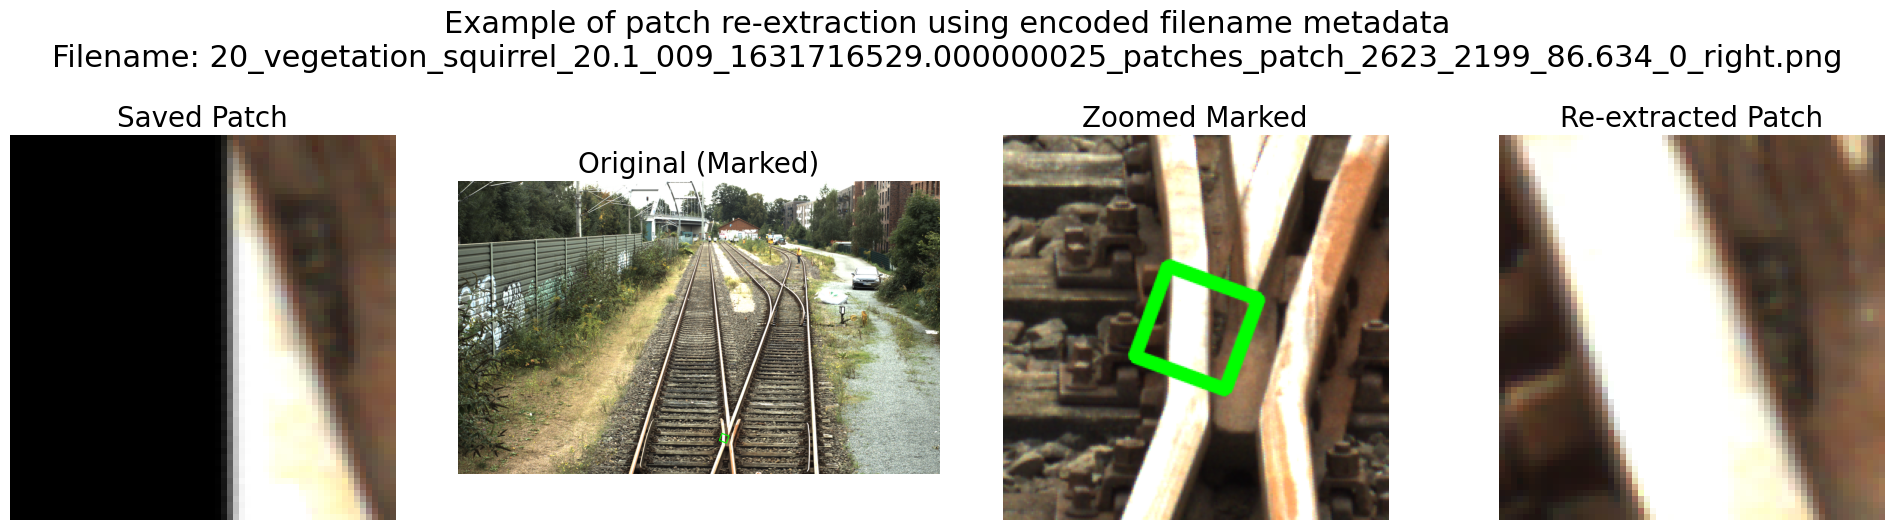

In [5]:
imgs = show_patch_on_og_img_and_reextract(
    patch_path="./sequential/patches_ts_black_prep2/1_calibration_1.2_054_1631441719.500000009_patches_patch_2270_2199_110.807_2_left.png",
    zoom_padding=4,showon=True
) #this is not masked properly because the points given aren't on the direction of the insight track but on the outside. (use print_image for checking it)


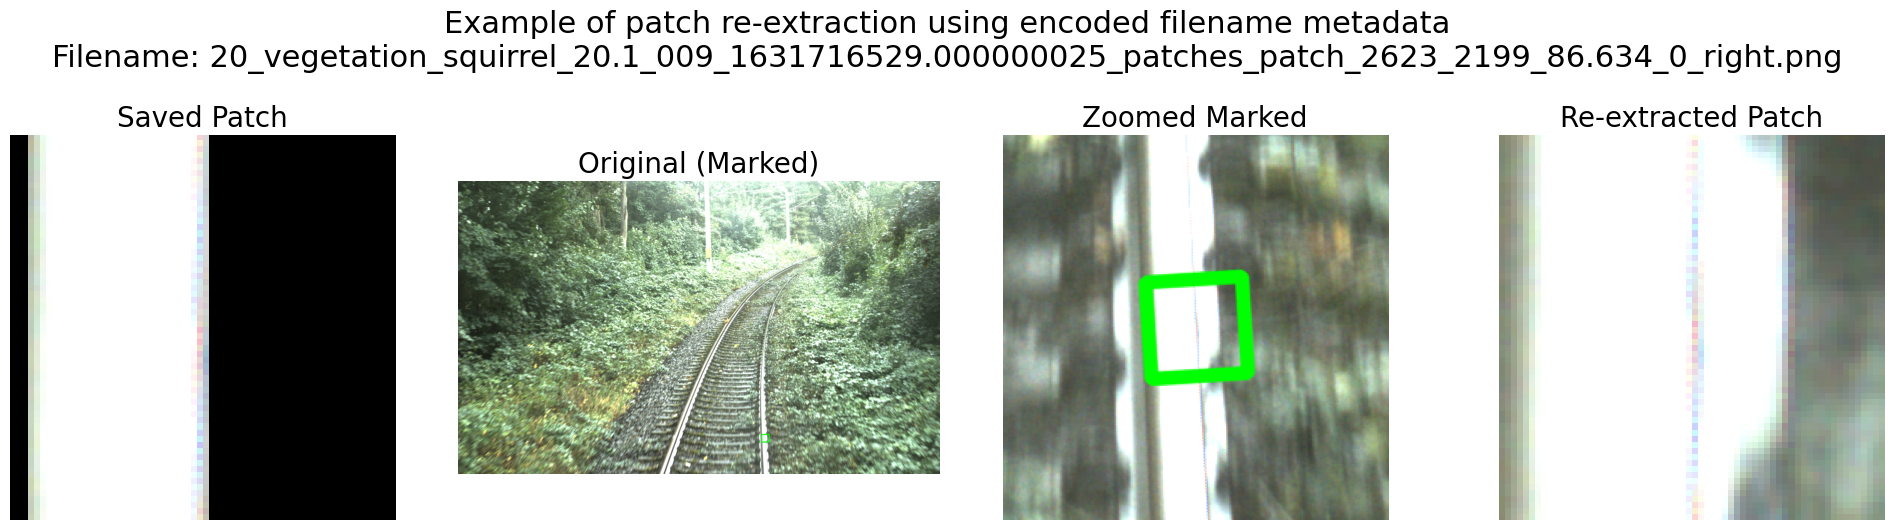

In [32]:
imgs = show_patch_on_og_img_and_reextract(
    patch_path="./sequential/patches_ts_black_prep2/20_vegetation_squirrel_20.1_009_1631716529.000000025_patches_patch_2623_2199_86.634_0_right.png",
    zoom_padding=4,showon=True
)


# Seperate the patches into defects, non-defects and patches that we dont want to use (for sequential dataset all are used but for static dataset not)

In [ ]:
source_folder     = r'./sequential/sequential_noprep/patches_ts_no_prep_unfolder' # Folder with the patches that we want to label
moved_folder_m    =  r'./sequential/sequential_noprep_labeled/sequential_noprep_defects'    # folder where the defective patches are moved (when “m” is pressed)

moved_folder_ent  = r'./sequential/sequential_noprep_labeled/sequential_noprep_good'      # folder where the good patches are moved (when Enter is pressed)
moved_folder_n  = r'./sequential/sequential_noprep_labeled/sequential_noprep_notsure'   # folder where the patches we dont want to use or we are unsure are moved (when 'n' is pressed)


# Window & zoom settingsm
window_name    = 'Image Review'
initial_width  = 200
initial_height = 200
zoom_factor    = 6


# Ensure destinations exist
os.makedirs(moved_folder_m,   exist_ok=True)
os.makedirs(moved_folder_ent, exist_ok=True)
os.makedirs(moved_folder_n, exist_ok=True)

IMAGE_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.gif'}
filenames = sorted(
    f for f in os.listdir(source_folder)
    if os.path.splitext(f)[1].lower() in IMAGE_EXTS
)

cv2.namedWindow(window_name, cv2.WINDOW_NORMAL)
cv2.resizeWindow(window_name, initial_width, initial_height)

for fname in filenames:
    src_path = os.path.join(source_folder, fname)
    img = cv2.imread(src_path)

    patch_path = src_path.replace("\\", "/")
    if img is None:
        print(f"Skipping unreadable file: {fname}")
        continue

    # Enlarge for visibility
    h, w = img.shape[:2]
    enlarged = cv2.resize(
        img,
        (w * zoom_factor, h * zoom_factor),
        
        interpolation=cv2.INTER_NEAREST
    )

    #original image
    imgs = show_patch_on_og_img_and_reextract( patch_path, zoom_padding = 5, showon=False)
    orig_img = imgs[2]
    orig_up = cv2.resize(
        orig_img,
        (w * zoom_factor, h * zoom_factor),
        interpolation=cv2.INTER_NEAREST
    )
    orig_up = cv2.cvtColor(orig_up, cv2.COLOR_RGB2BGR)


    # stitch them side by side
    combined = np.hstack([orig_up, enlarged])
    # combined = cv2.cvtColor(combined, cv2.COLOR_RGB2BGR)
    # (re)size the window to fit


    win_w = combined.shape[1]
    win_h = combined.shape[0]
    cv2.resizeWindow(window_name, win_w, win_h)

    cv2.imshow(window_name, combined)
    key = cv2.waitKey(0)

    if key == ord('m'):
        dst = os.path.join(moved_folder_m, fname)
        shutil.move(src_path, dst)
        print(f"Moved {fname} → {moved_folder_m}")
    elif key in (13, 10):  # Enter key
        dst = os.path.join(moved_folder_ent, fname)
        shutil.move(src_path, dst)
        print(f"Moved {fname} → {moved_folder_ent}")
    elif key == ord('n'):
        dst = os.path.join(moved_folder_n, fname)
        shutil.move(src_path, dst)
        print(f"Moved {fname} → {moved_folder_n}")
    elif key == ord('q'):
        
        print("Quitting.")
        break
    else:
        print("Unrecognized key, moving on.")
    cv2.destroyAllWindows()
    cv2.namedWindow(window_name, cv2.WINDOW_NORMAL)
    cv2.resizeWindow(window_name, initial_width, initial_height)

cv2.destroyAllWindows()






Moved 10_station_suelldorf_10.1_216_1631703820.700000022_patches_patch_1461_2199_105.524_0_left.png → ./train_track_only_ts/good
Moved 10_station_suelldorf_10.1_216_1631703820.700000022_patches_patch_2252_2199_80.668_0_right.png → ./train_track_only_ts/def
Moved 10_station_suelldorf_10.1_217_1631703820.800000017_patches_patch_1457_2199_106.027_0_left.png → ./train_track_only_ts/notsure
Quitting.


# Draw and save masks

In [ ]:
INPUT_DIR = r'./sequential/sequential_noprep_labeled/sequential_noprep_defects'     # folder with images with defects that we want to create masks
OUTPUT_DIR = r'./sequential/sequential_noprep_labeled/sequential_defective_masks'    # masks will be saved here (when `s` is pressed)

# Folder that images that were successfully masked are moved (when mask is drawn ans `s` is pressed to save it)-->after all done they were moved back to `patches_ts_black_prep2_defects` folder:
MASKED_IMG_DIR = r'./sequential/sequential_noprep_labeled/sequential_noprep_defects_maskcreated'  

os.makedirs(MASKED_IMG_DIR, exist_ok=True)

SKIPPED_IMG_DIR = r'./sequential/skipped_images' # Folder where images we skipped and no mask was created are moved (when `n` is pressed) -->in order to check them again until this folder becomes empty
os.makedirs(SKIPPED_IMG_DIR, exist_ok=True)

EXTS = (".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff")
         

os.makedirs(OUTPUT_DIR, exist_ok=True)


def list_images(folder):
    return [os.path.join(folder, f) for f in sorted(os.listdir(folder)) if f.lower().endswith(EXTS)]


class FreehandSelector:
    def __init__(self, ax, img_shape):
        self.ax = ax
        self.canvas = ax.figure.canvas
        self.img_shape = img_shape
        self.verts = None
        self.lasso = LassoSelector(ax, onselect=self.on_select)

    def on_select(self, verts):
        self.verts = verts
        self.ax.add_patch(plt.Polygon(verts, fill=False, edgecolor="red", lw=2))
        self.canvas.draw_idle()

    def mask(self):
        if self.verts is None:
            return None
        mask = np.zeros(self.img_shape[:2], np.uint8)
        cv2.fillPoly(mask, [np.array(self.verts, int)], 255)
        return mask


def try_widget_backend():
    """Return True if we manage to switch to ipympl backend."""
    ip = get_ipython()
    if ip is None:
        return False  # running as plain script
    if plt.get_backend().startswith("module://matplotlib_inline"):
        try:
            ip.run_line_magic("matplotlib", "widget")
            return True
        except Exception:
            return False
    # already on an interactive backend
    return True


def opencv_paint(patch_bgr, patch_path, zoom_factor=8):
    brush_size =7
    # Retrieve original image
    imgs = show_patch_on_og_img_and_reextract(patch_path, zoom_padding=5, showon=False)
    orig_rgb = imgs[2]
    orig_bgr = cv2.cvtColor(orig_rgb, cv2.COLOR_RGB2BGR)

    # Resize both images
    h, w = patch_bgr.shape[:2]
    patch_up = cv2.resize(patch_bgr, (w * zoom_factor, h * zoom_factor), interpolation=cv2.INTER_NEAREST)
    orig_up  = cv2.resize(orig_bgr,  (w * zoom_factor, h * zoom_factor), interpolation=cv2.INTER_NEAREST)

    # Prepare combined display image
    combined = np.hstack([orig_up, patch_up])
    display = combined.copy()

    # Initialize mask (same size as patch_up)
    mask = np.zeros(patch_up.shape[:2], np.uint8)
    drawing = False

    def on_mouse(event, x, y, flags, param):
        nonlocal drawing, display
        if x < orig_up.shape[1]:
            return  # Ignore mouse input on the original image side

        x_rel = x - orig_up.shape[1]  # Shift x to patch side
        if event == cv2.EVENT_LBUTTONDOWN:
            drawing = True
        elif event == cv2.EVENT_MOUSEMOVE and drawing:
            cv2.circle(mask, (x_rel, y), brush_size, 255, -1)
            cv2.circle(display[:, orig_up.shape[1]:], (x_rel, y), brush_size, (0, 0, 255), -1)
        elif event == cv2.EVENT_LBUTTONUP:
            drawing = False

    cv2.namedWindow("Draw mask , S:save  R:reset  N:next  Q:quit", cv2.WINDOW_NORMAL)
    cv2.setMouseCallback("Draw mask , S:save  R:reset  N:next  Q:quit", on_mouse)
    cv2.resizeWindow("Draw mask , S:save  R:reset  N:next  Q:quit", combined.shape[1], combined.shape[0])

    while True:
        cv2.imshow("Draw mask , S:save  R:reset  N:next  Q:quit", display)
        k = cv2.waitKey(1) & 0xFF
        if k in (ord("s"), ord("S")) and np.any(mask):
            cv2.destroyWindow("Draw mask , S:save  R:reset  N:next  Q:quit")
            # Resize mask back to original patch size before saving
            return cv2.resize(mask, (w, h), interpolation=cv2.INTER_NEAREST)
        elif k in (ord("r"), ord("R")):
            display = combined.copy()
            mask[:] = 0
        elif k in (ord("n"), ord("N")):
            cv2.destroyWindow("Draw mask , S:save  R:reset  N:next  Q:quit")
            return None
        elif k in (ord("q"), ord("Q")):
            cv2.destroyAllWindows()
            raise KeyboardInterrupt()
        elif k == ord(']'):
            brush_size = min(brush_size + 1, 100)
            print(f"Brush size increased to {brush_size}")
        elif k == ord('['):
            brush_size = max(brush_size - 1, 1)
            print(f"Brush size decreased to {brush_size}")

def process_images():
    use_widget = False #try_widget_backend()

    images = list_images(INPUT_DIR)
    if not images:
        print("No images found.")
        return

    for idx, path in enumerate(images, 1):
        print(f"[{idx}/{len(images)}] {os.path.basename(path)}")
        img_bgr = cv2.imread(path)
        if img_bgr is None:
            print("cannot open – skipped")
            continue

        if use_widget:
            # Show in-notebook widget
            img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
            fig, ax = plt.subplots()
            ax.imshow(img_rgb)
            ax.set_title("Close figure when done drawing")
            ax.axis("off")
            sel = FreehandSelector(ax, img_bgr.shape)
            plt.show()  # blocks
            mask = sel.mask()
            plt.close(fig)
        else:
            # Fall back to OpenCV GUI
            patch_path = path.replace("\\", "/")  
            mask = opencv_paint(img_bgr, patch_path)
            # mask = opencv_paint(img_bgr)

        if mask is None:
            print("no mask drawn , skipped")
            skipped_name = os.path.basename(path)
            shutil.move(path, os.path.join(SKIPPED_IMG_DIR, skipped_name))
            continue


        out_name = os.path.splitext(os.path.basename(path))[0] + "_mask.png"
        cv2.imwrite(os.path.join(OUTPUT_DIR, out_name), mask)
        print("saved", out_name)

        shutil.move(path, os.path.join(MASKED_IMG_DIR, os.path.basename(path)))

    print("Done , masks written to", OUTPUT_DIR)


try:
    process_images()
except KeyboardInterrupt:
    print("Interrupted by user , masks so far are saved.")

    



[1/6] 1_calibration_1.2_044_1631441718.500000013_patches_patch_2938_2199_89.784_2_right.png
Brush size decreased to 6
Brush size decreased to 5
Brush size decreased to 4
Brush size decreased to 3
Brush size decreased to 2
saved 1_calibration_1.2_044_1631441718.500000013_patches_patch_2938_2199_89.784_2_right_mask.png
[2/6] 1_calibration_1.2_046_1631441718.700000019_patches_patch_1551_2199_107.526_0_left.png
Brush size decreased to 6
Brush size decreased to 5
Brush size decreased to 4
Brush size decreased to 3
saved 1_calibration_1.2_046_1631441718.700000019_patches_patch_1551_2199_107.526_0_left_mask.png
[3/6] 1_calibration_1.2_060_1631441720.100000008_patches_patch_2343_2199_84.000_0_right.png
Brush size decreased to 6
Brush size decreased to 5
Brush size decreased to 4
Brush size decreased to 3
Brush size decreased to 2
Brush size decreased to 1
Brush size increased to 2
Brush size increased to 3
Brush size increased to 4
Brush size increased to 5
saved 1_calibration_1.2_060_16314417

# Based on the labels of the noprep folder, create labeled folders of all the 5 differently preprocessed datasets

In [ ]:

base_dir = os.getcwd() 

label_base = os.path.join(base_dir, "sequential/sequential_noprep_labeled")
def_folder = os.path.join(label_base, "sequential_noprep_defects_maskcreated")
good_folder = os.path.join(label_base, "sequential_noprep_good")
mask_folder = os.path.join(label_base, "sequential_defective_masks")  

#5 target folders 
target_folders = [
    os.path.join(base_dir, "sequential/patches_ts_black_prep2"),
    os.path.join(base_dir, "sequential/blur_backround_images"),
    os.path.join(base_dir, "sequential/blurclahe_images"),
    os.path.join(base_dir, "sequential/blackclahe_images"),
    os.path.join(base_dir, "sequential/blurclahebw_images")
]


# Collect filenames for matching the patches
def_files = set(os.listdir(def_folder))
good_files = set(os.listdir(good_folder))

for target in target_folders:
    if not os.path.exists(target):
        print(f"Skipping {target} (does not exist)")
        continue

    folder_name = os.path.basename(target)
    labeled_root = os.path.join(target, f"{folder_name}_labeled")
    os.makedirs(labeled_root, exist_ok=True)

    print(f"\nProcessing: {target} → {labeled_root}")

    # create labeled subfolders
    def_dest = os.path.join(labeled_root, f"{folder_name}_defects")
    good_dest = os.path.join(labeled_root, f"{folder_name}_good")
    mask_dest = os.path.join(labeled_root, "sequential_defective_masks")

    os.makedirs(def_dest, exist_ok=True)
    os.makedirs(good_dest, exist_ok=True)

    # copy photos into def/good
    for fname in os.listdir(target):
        src = os.path.join(target, fname)
        if not os.path.isfile(src):
            continue
        if fname in def_files:
            shutil.copy2(src, os.path.join(def_dest, fname))
        elif fname in good_files:
            shutil.copy2(src, os.path.join(good_dest, fname))

    # copy the full defective_masks folder
    if os.path.exists(mask_dest):
        shutil.rmtree(mask_dest)
    shutil.copytree(mask_folder, mask_dest)

    print(f"Done for {folder_name}")

print("\nAll folders processed successfully.")
